<a href="https://colab.research.google.com/github/satine002/GE234_BasicProgramming/blob/main/Lab5_GE234_Rasterio_6706615009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [6]:
import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/drive/MyDrive/GEE_Exports/ratchaburi_raster.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)

ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 10107, 'height': 8903, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 99.16214960504479,
       0.0, -8.983152841195215e-05, 13.944368492330508)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


In [ ]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


In [ ]:

import numpy as np

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()



## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [ ]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [ ]:

from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "boundary.shp"  # ใส่ path ของไฟล์ขอบเขต
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


**แบบฝึกหัด 1:** ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

In [ ]:
# เชื่อมต่อ drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import rasterio

# เปิดไฟล์ Raster
raster_path = "/content/drive/MyDrive/GEE_Exports/ratchaburi_raster.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)

ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 10107, 'height': 8903, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 99.16214960504479,
       0.0, -8.983152841195215e-05, 13.944368492330508)}


**แบบฝึกหัด 2:** ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [10]:
import rasterio

# ตรวจสอบให้แน่ใจว่า raster_path ถูกกำหนดไว้แล้ว
# ตัวอย่าง: raster_path = "/content/drive/MyDrive/GEE_Exports/ratchaburi_raster.tif"

with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(f"  Driver: {dataset.driver}")
    print(f"  Data Type (dtype): {dataset.meta['dtype']}")
    print(f"  NoData Value: {dataset.meta['nodata']}")
    print(f"  Width: {dataset.width} pixels")
    print(f"  Height: {dataset.height} pixels")
    print(f"  Number of Bands (count): {dataset.count}")
    print(f"  Coordinate Reference System (CRS): {dataset.crs}")
    print(f"  Transform (Affine matrix): {dataset.transform}")

    print("\n--- คำอธิบายเพิ่มเติม --- ")
    print("  Driver: รูปแบบของไฟล์ Raster เช่น 'GTiff' หมายถึง GeoTIFF")
    print("  Data Type (dtype): ชนิดข้อมูลของแต่ละพิกเซล เช่น 'float64' หมายถึงตัวเลขทศนิยม 64 บิต")
    print("  NoData Value: ค่าพิกเซลที่ถูกกำหนดให้ไม่มีข้อมูล (มักใช้เพื่อละเว้นในการวิเคราะห์)")
    print("  Width/Height: ขนาดของภาพ Raster ในหน่วยพิกเซล (คอลัมน์/แถว)")
    print("  Number of Bands (count): จำนวนแบนด์ข้อมูลในภาพ (เช่น ภาพสี RGB มี 3 แบนด์)")
    print("  CRS (Coordinate Reference System): ระบบพิกัดภูมิศาสตร์ที่ภาพนี้อ้างอิง เช่น WGS 84 (ละติจูด/ลองจิจูด)")
    print("  Transform: เมทริกซ์การแปลงทาง Affine ที่ใช้อธิบายตำแหน่ง, ขนาดพิกเซล, และการหมุนของภาพในพิกัดภูมิศาสตร์")

ข้อมูลเมตาของภาพ Raster:
  Driver: GTiff
  Data Type (dtype): float64
  NoData Value: None
  Width: 10107 pixels
  Height: 8903 pixels
  Number of Bands (count): 4
  Coordinate Reference System (CRS): EPSG:4326
  Transform (Affine matrix): | 0.00, 0.00, 99.16|
| 0.00,-0.00, 13.94|
| 0.00, 0.00, 1.00|

--- คำอธิบายเพิ่มเติม --- 
  Driver: รูปแบบของไฟล์ Raster เช่น 'GTiff' หมายถึง GeoTIFF
  Data Type (dtype): ชนิดข้อมูลของแต่ละพิกเซล เช่น 'float64' หมายถึงตัวเลขทศนิยม 64 บิต
  NoData Value: ค่าพิกเซลที่ถูกกำหนดให้ไม่มีข้อมูล (มักใช้เพื่อละเว้นในการวิเคราะห์)
  Width/Height: ขนาดของภาพ Raster ในหน่วยพิกเซล (คอลัมน์/แถว)
  Number of Bands (count): จำนวนแบนด์ข้อมูลในภาพ (เช่น ภาพสี RGB มี 3 แบนด์)
  CRS (Coordinate Reference System): ระบบพิกัดภูมิศาสตร์ที่ภาพนี้อ้างอิง เช่น WGS 84 (ละติจูด/ลองจิจูด)
  Transform: เมทริกซ์การแปลงทาง Affine ที่ใช้อธิบายตำแหน่ง, ขนาดพิกเซล, และการหมุนของภาพในพิกัดภูมิศาสตร์


**แบบฝึกหัด 3:** ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

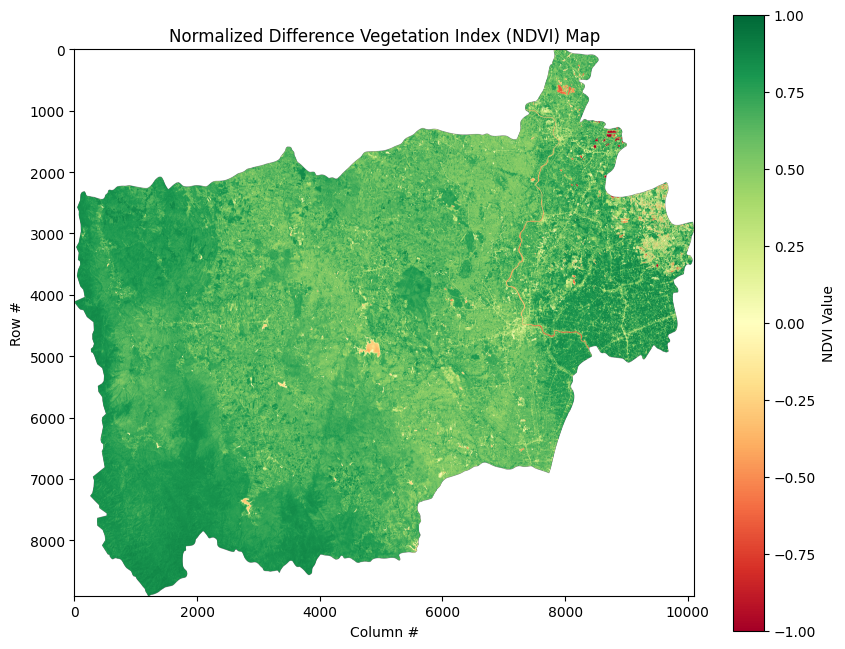

In [11]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# ตรวจสอบให้แน่ใจว่า raster_path ถูกกำหนดไว้แล้ว
# ตัวอย่าง: raster_path = "/content/drive/MyDrive/GEE_Exports/ratchaburi_raster.tif"

# เปิดไฟล์ภาพ
with rasterio.open(raster_path) as dataset:
    # อ่านBand NIR และ Red
    # สมมติว่า Band 4 คือ NIR และ Band 3 คือ Red
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
# เพิ่มค่า 1e-10 ในส่วนหารเพื่อหลีกเลี่ยงการหารด้วยศูนย์
ndvi = (nir - red) / (nir + red + 1e-10)

# แสดงผล NDVI
plt.figure(figsize=(10, 8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI) Map")
plt.xlabel("Column #")
plt.ylabel("Row #")
plt.show()

**แบบฝึกหัด 4:** ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

In [15]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import rasterio

# ตรวจสอบให้แน่ใจว่า raster_path ถูกกำหนดไว้แล้ว
# เช่น raster_path = "/content/drive/MyDrive/GEE_Exports/ratchaburi_raster.tif"

# กำหนด path ของไฟล์ Shapefile ที่ต้องการใช้ตัด
shapefile_path = "/content/drive/MyDrive/GEE_Exports/ApBP/BP.shp"

try:
    # โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
    gdf = gpd.read_file(shapefile_path)

    # แปลง Polygon จาก GeoPandas GeoDataFrame เป็นรูปแบบ GeoJSON
    geometry = [mapping(geom) for geom in gdf.geometry]

    # ตัดภาพ Raster
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, geometry, crop=True)
        out_meta = src.meta.copy()

    # อัปเดตเมตาดาต้าใหม่สำหรับภาพที่ถูกตัด
    out_meta.update({"height": out_image.shape[1],
                       "width": out_image.shape[2],
                       "transform": out_transform,
                       "nodata": src.nodata
                      })

    # บันทึกไฟล์ที่ถูกตัด
    clipped_raster_output_path = "clipped_ratchaburi_raster.tif"
    with rasterio.open(clipped_raster_output_path, "w", **out_meta) as dest:
        dest.write(out_image)

    print(f"ตัดข้อมูล Raster สำเร็จ! ไฟล์ถูกบันทึกที่: {clipped_raster_output_path}")

except FileNotFoundError:
    print(f"ข้อผิดพลาด: ไม่พบไฟล์ Shapefile ที่: {shapefile_path}")
    print("โปรดตรวจสอบว่า path ของไฟล์ Shapefile ถูกต้อง")
except Exception as e:
    print(f"เกิดข้อผิดพลาดในการตัดข้อมูล: {e}")
    print("โปรดตรวจสอบว่าไฟล์ Shapefile และ Raster มี CRS ที่เข้ากันได้")

ตัดข้อมูล Raster สำเร็จ! ไฟล์ถูกบันทึกที่: clipped_ratchaburi_raster.tif


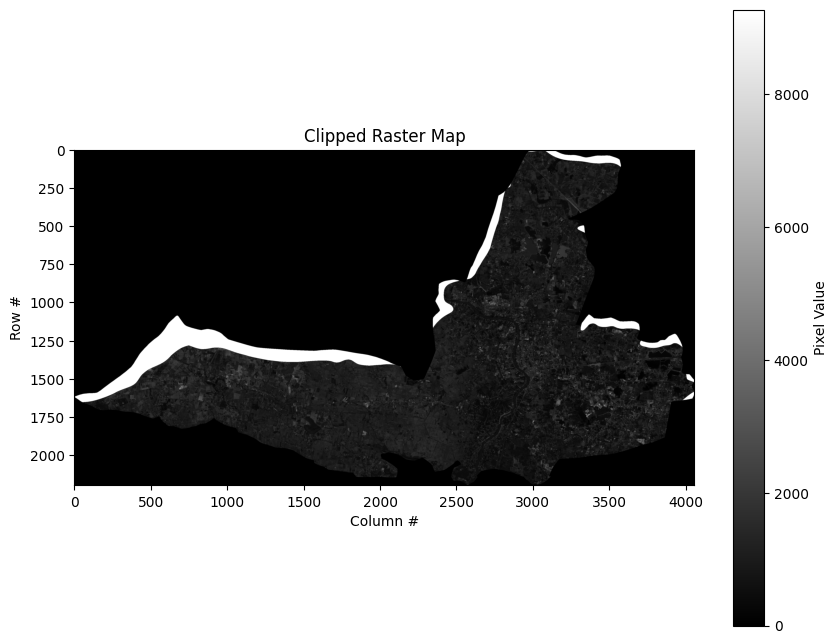

In [14]:
import matplotlib.pyplot as plt

# เปิดไฟล์ Raster ที่ถูกตัดเพื่อแสดงผล
with rasterio.open(clipped_raster_output_path) as dataset:
    # อ่าน Band แรกของภาพที่ถูกตัด
    clipped_band = dataset.read(1)

    # แสดงภาพ Raster ที่ถูกตัด
    plt.figure(figsize=(10, 8))
    plt.imshow(clipped_band, cmap='gray')
    plt.colorbar(label='Pixel Value')
    plt.title('Clipped Raster Map')
    plt.xlabel('Column #')
    plt.ylabel('Row #')
    plt.show()